# Assignment 5 – Decision Tree (ID3)
**Cairo University – Faculty of Engineering**  
**Introduction to Machine Learning**

**Name: Raghad Abdelhameed**

This notebook is divided into four sections:
1. **Section 1** – Data reading & preprocessing (Heart Disease dataset)
2. **Section 2** – From-scratch ID3 implementation + results
3. **Section 3** – `decision-tree-id3` library + comparison
4. **Section 4** – From-scratch tree on student data + visualisation

---
## Section 1 – Data Reading & Preprocessing

In [1]:
#  Imports
import numpy as np
import pandas as pd
import math
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import KBinsDiscretizer

In [2]:
#  1.1  Load the dataset
df = pd.read_csv('heart_disease.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1024, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0,0


In [3]:
#  1.2  Inspect dtypes and missing values
print('Data types:')
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isnull().sum())

Data types:
age              float64
sex                int64
cp                 int64
trestbps         float64
chol             float64
fbs                int64
restecg            int64
thalach          float64
exang              int64
oldpeak          float64
slope              int64
ca               float64
thal             float64
num                int64
target_binary      int64
dtype: object

Missing values per column:
age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               0
thal             0
num              0
target_binary    0
dtype: int64


In [4]:
#  1.3  Define feature groups
TARGET = 'target_binary'   # binary label: 0 = no disease, 1 = disease

# Already discrete columns (integer-valued)
discrete_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'num']

# Continuous columns that need discretisation
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']

print('Discrete features :', discrete_cols)
print('Continuous features:', continuous_cols)

Discrete features : ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'num']
Continuous features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']


In [5]:
# ── 1.4  Discretise continuous features (equal-frequency binning) ─
# We use 3 bins per feature. Equal-frequency (quantile) binning
# ensures each bin has approximately the same number of samples,
# which is more robust than equal-width for skewed distributions.

df_disc = df.copy()

N_BINS = 3  # low / medium / high
bin_labels = {}

for col in continuous_cols:
    df_disc[col], bins = pd.qcut(
        df_disc[col], q=N_BINS, labels=False, retbins=True, duplicates='drop'
    )
    bin_labels[col] = bins

print('Discretisation complete. Unique values per continuous column:')
for col in continuous_cols:
    print(f'  {col}: {sorted(df_disc[col].unique())}')

Discretisation complete. Unique values per continuous column:
  age: [np.int64(0), np.int64(1), np.int64(2)]
  trestbps: [np.int64(0), np.int64(1), np.int64(2)]
  chol: [np.int64(0), np.int64(1), np.int64(2)]
  thalach: [np.int64(0), np.int64(1), np.int64(2)]
  oldpeak: [np.int64(0), np.int64(1), np.int64(2)]
  ca: [np.int64(0), np.int64(1)]
  thal: [np.int64(0)]


In [6]:
#  1.5  Drop 'num' column (target leak – it encodes disease severity)
# 'target_binary' is derived from 'num', so keeping 'num' would cause
# a direct information leak into the model.
df_disc.drop(columns=['num'], inplace=True)

#  1.6  Final feature set
FEATURES = [c for c in df_disc.columns if c != TARGET]
print(f'Features ({len(FEATURES)}):', FEATURES)
print(f'Target: {TARGET}')
print()
print('Class distribution:')
print(df_disc[TARGET].value_counts())

Features (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target: target_binary

Class distribution:
target_binary
0    554
1    470
Name: count, dtype: int64


In [7]:
#  1.7  Train / Test split (80 / 20, stratified)
X = df_disc[FEATURES]
y = df_disc[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

Training samples : 819
Test samples     : 205


---
## Section 2 – From-Scratch ID3 Decision Tree

In [8]:
# ══════════════════════════════════════════════════════════
# From-Scratch ID3 Implementation
# ══════════════════════════════════════════════════════════

# Node class
class TreeNode:
    """
    Represents a single node in the ID3 decision tree.

    Attributes
    ----------
    feature : str or None
        The feature name used for splitting at this node.
        None for leaf nodes.
    value : int/float or None
        The class label at a leaf node. None for internal nodes.
    children : dict
        Maps each feature value to a child TreeNode.
    """
    def __init__(self, feature=None, value=None):
        self.feature  = feature   # splitting feature (internal node)
        self.value    = value     # class label (leaf node)
        self.children = {}        # {feature_value: TreeNode}


#  Entropy
def entropy(labels):
    """
    Compute Shannon entropy H(S) = -Σ p_i * log2(p_i).

    Parameters
    ----------
    labels : array-like of int
        Class labels for a set of samples.

    Returns
    -------
    float : entropy value (in bits).
    """
    n = len(labels)
    if n == 0:
        return 0.0
    counts = Counter(labels)
    return -sum(
        (c / n) * math.log2(c / n)
        for c in counts.values() if c > 0
    )


#  Information Gain
def information_gain(df, feature, target):
    """
    Compute Information Gain for splitting df on `feature`.

    IG(S, A) = H(S) - Σ_v (|S_v|/|S|) * H(S_v)

    Parameters
    ----------
    df      : pd.DataFrame – the current subset of training data.
    feature : str         – feature column to evaluate.
    target  : str         – target label column.

    Returns
    -------
    float : information gain value.
    """
    total_entropy = entropy(df[target])
    n = len(df)

    weighted_entropy = 0.0
    for val in df[feature].unique():
        subset = df[df[feature] == val]
        weighted_entropy += (len(subset) / n) * entropy(subset[target])

    return total_entropy - weighted_entropy


#  ID3 Tree Builder
def id3_build(df, features, target, depth=0, max_depth=None):
    """
    Recursively build an ID3 decision tree.

    Stopping conditions:
      - All samples have the same class label → leaf.
      - No features left to split on → leaf (majority vote).
      - Maximum depth reached → leaf (majority vote).
      - No samples in subset → returns None (handled by caller).

    Parameters
    ----------
    df        : pd.DataFrame – current subset.
    features  : list[str]    – remaining features available for splitting.
    target    : str          – target column name.
    depth     : int          – current depth (used for max_depth check).
    max_depth : int or None  – maximum allowed tree depth (None = unlimited).

    Returns
    -------
    TreeNode : root of the (sub)tree.
    """
    labels = df[target].tolist()
    majority = Counter(labels).most_common(1)[0][0]

    # Stop: pure node
    if len(set(labels)) == 1:
        return TreeNode(value=labels[0])

    # Stop: no features left or max depth reached
    if not features or (max_depth is not None and depth >= max_depth):
        return TreeNode(value=majority)

    # Pick feature with highest information gain
    best_feature = max(features, key=lambda f: information_gain(df, f, target))

    node = TreeNode(feature=best_feature)

    remaining = [f for f in features if f != best_feature]

    for val in df[best_feature].unique():
        subset = df[df[best_feature] == val]
        if subset.empty:
            node.children[val] = TreeNode(value=majority)
        else:
            node.children[val] = id3_build(
                subset, remaining, target, depth + 1, max_depth
            )

    return node


#  Predict a single sample
def predict_one(node, sample, default=0):
    """
    Traverse the tree to predict the class for a single sample.

    Parameters
    ----------
    node    : TreeNode    – root (or current) node.
    sample  : pd.Series   – one row of feature values.
    default : int         – fallback label if a branch is unseen.

    Returns
    -------
    int : predicted class label.
    """
    if node.value is not None:           # leaf node
        return node.value
    feature_val = sample[node.feature]
    if feature_val not in node.children: # unseen value at test time
        return default
    return predict_one(node.children[feature_val], sample, default)


#  Predict for a DataFrame
def predict(tree, X_df, default=0):
    """
    Generate predictions for all rows in X_df.

    Parameters
    ----------
    tree    : TreeNode   – trained decision tree root.
    X_df    : pd.DataFrame – feature matrix.
    default : int         – fallback for unseen branches.

    Returns
    -------
    np.ndarray : array of predicted class labels.
    """
    return np.array([predict_one(tree, row, default) for _, row in X_df.iterrows()])


print('ID3 implementation defined successfully.')

ID3 implementation defined successfully.


In [9]:
#  2.1  Prepare data for scratch model
train_df = X_train.copy()
train_df[TARGET] = y_train.values

test_df  = X_test.copy()
test_df[TARGET]  = y_test.values

In [10]:
#  2.2  Train
start_train = time.perf_counter()
scratch_tree = id3_build(train_df, FEATURES, TARGET, max_depth=None)
scratch_train_time = time.perf_counter() - start_train

print(f'Training time (scratch): {scratch_train_time:.4f} s')

Training time (scratch): 1.0168 s


In [11]:
#  2.3  Predict & Evaluate
start_pred = time.perf_counter()
y_pred_scratch = predict(scratch_tree, X_test)
scratch_pred_time = time.perf_counter() - start_pred

scratch_acc = accuracy_score(y_test, y_pred_scratch)

print(f'Prediction time (scratch): {scratch_pred_time:.4f} s')
print(f'Test Accuracy   (scratch): {scratch_acc:.4f}')

Prediction time (scratch): 0.0091 s
Test Accuracy   (scratch): 0.7317


---
## Section 3 – `decision-tree-id3` Library

In [12]:
# Install the library (run once in Colab)
!pip install decision-tree-id3 six

# Compatibility fix: decision-tree-id3 uses sklearn.externals.six
# which was removed in newer sklearn versions. We patch it manually.
import sys
try:
    import six
    import sklearn.externals
    sys.modules['sklearn.externals.six'] = six
except ImportError:
    pass  # Not needed on older environments

# Also patch np.float deprecation in the library (numpy >= 1.24)
import numpy as np
if not hasattr(np, 'float'):
    np.float = float

from id3 import Id3Estimator

print('Library imported successfully.')

Library imported successfully.


In [13]:
#  3.1  Train
lib_model = Id3Estimator()

start_train_lib = time.perf_counter()
lib_model.fit(X_train.values, y_train.values)
lib_train_time = time.perf_counter() - start_train_lib

print(f'Training time (library): {lib_train_time:.4f} s')


Training time (library): 0.1993 s


In [14]:
#  3.2  Predict & Evaluate
start_pred_lib = time.perf_counter()
y_pred_lib = lib_model.predict(X_test.values)
lib_pred_time = time.perf_counter() - start_pred_lib

lib_acc = accuracy_score(y_test, y_pred_lib)

print(f'Prediction time (library): {lib_pred_time:.4f} s')
print(f'Test Accuracy   (library): {lib_acc:.4f}')

Prediction time (library): 0.0030 s
Test Accuracy   (library): 0.7415


In [15]:
# ─ 3.3  Comparison table
comparison = pd.DataFrame({
    'Model'          : ['From-Scratch ID3', 'Library ID3'],
    'Accuracy'       : [scratch_acc, lib_acc],
    'Training Time'  : [scratch_train_time, lib_train_time],
    'Prediction Time': [scratch_pred_time, lib_pred_time],
})
comparison = comparison.set_index('Model')
comparison['Accuracy']        = comparison['Accuracy'].map('{:.4f}'.format)
comparison['Training Time']   = comparison['Training Time'].map('{:.4f} s'.format)
comparison['Prediction Time'] = comparison['Prediction Time'].map('{:.6f} s'.format)
print(comparison.to_string())


                 Accuracy Training Time Prediction Time
Model                                                  
From-Scratch ID3   0.7317      1.0168 s      0.009052 s
Library ID3        0.7415      0.1993 s      0.003002 s


In [16]:
# Store raw numbers for PDF
results = {
    'scratch_acc'       : scratch_acc,
    'lib_acc'           : lib_acc,
    'scratch_train_time': scratch_train_time,
    'lib_train_time'    : lib_train_time,
    'scratch_pred_time' : scratch_pred_time,
    'lib_pred_time'     : lib_pred_time,
}

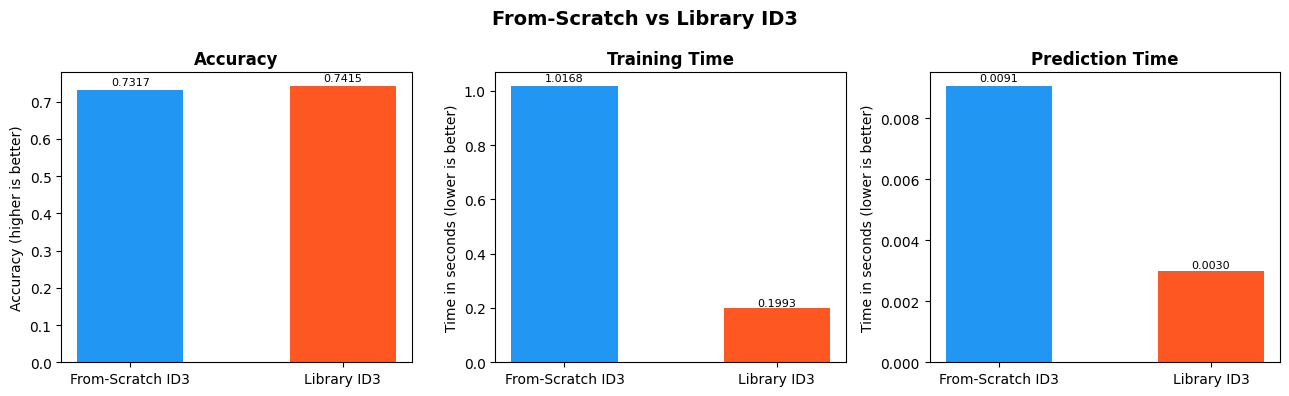

Chart saved as comparison_chart.png


In [17]:
#  3.4  Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

metrics = [
    ('Accuracy',        [scratch_acc, lib_acc],           'Accuracy (higher is better)'),
    ('Training Time',   [scratch_train_time, lib_train_time], 'Time in seconds (lower is better)'),
    ('Prediction Time', [scratch_pred_time, lib_pred_time], 'Time in seconds (lower is better)'),
]

colors = ['#2196F3', '#FF5722']
labels = ['From-Scratch ID3', 'Library ID3']

for ax, (title, vals, ylabel) in zip(axes, metrics):
    bars = ax.bar(labels, vals, color=colors, width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('From-Scratch vs Library ID3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as comparison_chart.png')

---
## Section 4 – From-Scratch ID3 on Student Data

In [18]:
#  4.1  Student dataset (Part 3)
# Attributes: Studies_Regularly, Attends_Lectures, Senior,
#             Works_Part_time, Likes_Course → Pass

student_data = pd.DataFrame({
    'Studies_Regularly': [1,1,0,0,0,0,1,0,0,1,1,0,0,1],
    'Attends_Lectures' : [1,1,0,1,1,0,0,1,0,0,1,1,0,0],
    'Senior'           : [0,1,1,1,1,1,0,0,1,0,1,1,0,0],
    'Works_Part_time'  : [0,0,0,0,1,1,0,1,0,0,0,1,0,1],
    'Likes_Course'     : [1,1,0,1,0,1,1,1,1,0,0,1,1,0],
    'Pass'             : [1,1,0,0,1,1,0,1,1,0,1,0,0,1],
})

S_FEATURES = ['Studies_Regularly','Attends_Lectures','Senior','Works_Part_time','Likes_Course']
S_TARGET   = 'Pass'

print('Student dataset:')
print(student_data.to_string(index=False))

Student dataset:
 Studies_Regularly  Attends_Lectures  Senior  Works_Part_time  Likes_Course  Pass
                 1                 1       0                0             1     1
                 1                 1       1                0             1     1
                 0                 0       1                0             0     0
                 0                 1       1                0             1     0
                 0                 1       1                1             0     1
                 0                 0       1                1             1     1
                 1                 0       0                0             1     0
                 0                 1       0                1             1     1
                 0                 0       1                0             1     1
                 1                 0       0                0             0     0
                 1                 1       1                0             0     1

In [19]:
# 4.2  Show entropy / IG calculations for root node
print('=== Root-Node Entropy / Information Gain Calculations ===\n')

labels = student_data[S_TARGET].tolist()
H_S = entropy(labels)
n   = len(labels)
pos = labels.count(1)
neg = labels.count(0)

print(f'Dataset size : {n}')
print(f'Pass=1       : {pos}   Pass=0: {neg}')
print(f'H(S)         = -({pos}/{n})*log2({pos}/{n}) - ({neg}/{n})*log2({neg}/{n})')
print(f'           = {H_S:.6f} bits\n')

print(f'{"Feature":<22} {"IG":>10}')
print('-' * 35)
ig_results = {}
for f in S_FEATURES:
    ig = information_gain(student_data, f, S_TARGET)
    ig_results[f] = ig
    print(f'{f:<22} {ig:>10.6f}')

best = max(ig_results, key=ig_results.get)
print(f'\n→ Best root feature: {best} (IG = {ig_results[best]:.6f})')

=== Root-Node Entropy / Information Gain Calculations ===

Dataset size : 14
Pass=1       : 8   Pass=0: 6
H(S)         = -(8/14)*log2(8/14) - (6/14)*log2(6/14)
           = 0.985228 bits

Feature                        IG
-----------------------------------
Studies_Regularly        0.020244
Attends_Lectures         0.061054
Senior                   0.011266
Works_Part_time          0.090276
Likes_Course             0.001340

→ Best root feature: Works_Part_time (IG = 0.090276)


In [20]:
#  4.3  Fit tree on full student dataset
student_tree = id3_build(student_data, S_FEATURES, S_TARGET, max_depth=None)

# Training accuracy (using all 14 samples)
y_s_pred = predict(student_tree, student_data[S_FEATURES])
s_acc    = accuracy_score(student_data[S_TARGET], y_s_pred)
print(f'Student tree training accuracy: {s_acc:.4f}')

Student tree training accuracy: 1.0000


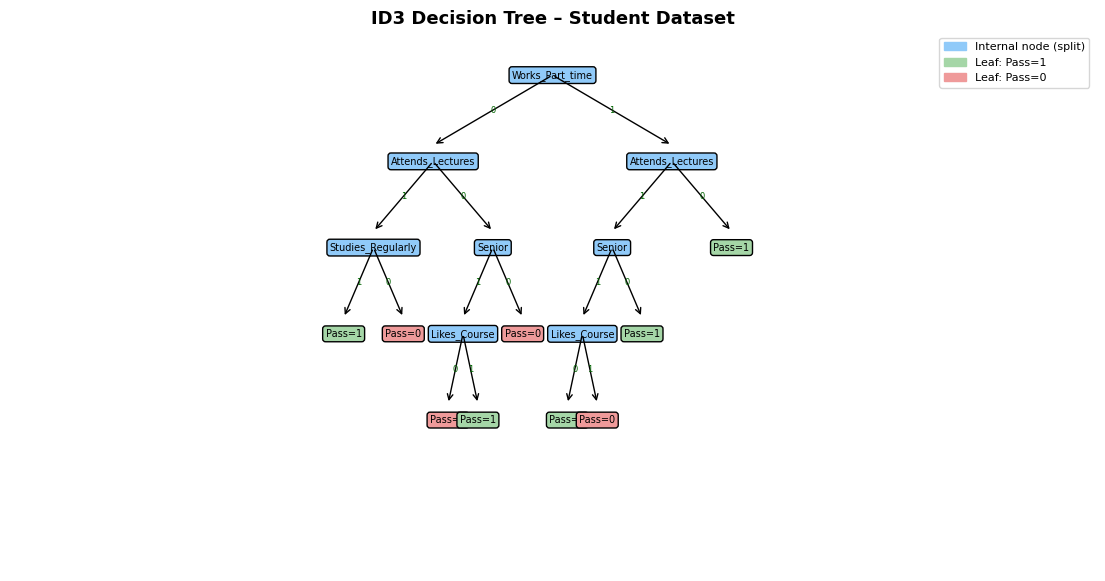

Tree visualisation saved as student_tree.png


In [21]:
#  4.4  Visualise the student tree

def draw_tree(node, ax, x=0.5, y=0.95, dx=0.25, dy=0.15,
              parent_xy=None, edge_label=''):
    """
    Recursively draw the decision tree using matplotlib.

    Parameters
    ----------
    node       : TreeNode – current node to draw.
    ax         : matplotlib Axes object.
    x, y       : float – normalised position of this node.
    dx, dy     : float – horizontal / vertical step size.
    parent_xy  : tuple or None – parent (x, y) for drawing edge.
    edge_label : str – label to place on the incoming edge.
    """
    if node is None:
        return

    is_leaf = (node.value is not None)
    color   = '#A5D6A7' if (is_leaf and node.value == 1) else \
              '#EF9A9A' if (is_leaf and node.value == 0) else '#90CAF9'
    label   = f'Pass={node.value}' if is_leaf else node.feature

    box = dict(boxstyle='round,pad=0.3', facecolor=color, edgecolor='black')
    ax.text(x, y, label, ha='center', va='center', fontsize=7,
            bbox=box, transform=ax.transAxes)

    if parent_xy:
        ax.annotate('', xy=(x, y + 0.03),
                    xytext=parent_xy,
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='black', lw=1))
        mid_x = (x + parent_xy[0]) / 2
        mid_y = (y + 0.03 + parent_xy[1]) / 2
        ax.text(mid_x, mid_y, str(edge_label),
                ha='center', va='center', fontsize=6, color='darkgreen',
                transform=ax.transAxes)

    if not is_leaf:
        children = list(node.children.items())
        n_children = len(children)
        x_start = x - dx * (n_children - 1) / 2
        for i, (val, child) in enumerate(children):
            child_x = x_start + i * dx
            child_y = y - dy
            draw_tree(child, ax, child_x, child_y, dx / 2, dy,
                      parent_xy=(x, y), edge_label=val)


fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')
ax.set_title('ID3 Decision Tree – Student Dataset', fontsize=13, fontweight='bold')

draw_tree(student_tree, ax, x=0.5, y=0.92, dx=0.22, dy=0.16)

# Legend
legend_items = [
    mpatches.Patch(color='#90CAF9', label='Internal node (split)'),
    mpatches.Patch(color='#A5D6A7', label='Leaf: Pass=1'),
    mpatches.Patch(color='#EF9A9A', label='Leaf: Pass=0'),
]
ax.legend(handles=legend_items, loc='upper right', fontsize=8)

plt.savefig('student_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tree visualisation saved as student_tree.png')

In [22]:
# 4.5  Print decision rules
def print_rules(node, prefix='', features_used=None):
    """
    Recursively print all root-to-leaf decision rules.

    Parameters
    ----------
    node          : TreeNode – current node.
    prefix        : str      – accumulated condition string.
    features_used : list     – conditions accumulated so far.
    """
    if features_used is None:
        features_used = []

    if node.value is not None:  # leaf
        rule = ' AND '.join(features_used) if features_used else 'TRUE'
        print(f'  IF {rule}  →  Pass = {node.value}')
        return

    for val, child in node.children.items():
        condition = f'{node.feature} = {val}'
        print_rules(child, prefix + condition + ' → ',
                    features_used + [condition])


print('Decision Rules for Student Tree:')
print('=' * 60)
print_rules(student_tree)

Decision Rules for Student Tree:
  IF Works_Part_time = 0 AND Attends_Lectures = 1 AND Studies_Regularly = 1  →  Pass = 1
  IF Works_Part_time = 0 AND Attends_Lectures = 1 AND Studies_Regularly = 0  →  Pass = 0
  IF Works_Part_time = 0 AND Attends_Lectures = 0 AND Senior = 1 AND Likes_Course = 0  →  Pass = 0
  IF Works_Part_time = 0 AND Attends_Lectures = 0 AND Senior = 1 AND Likes_Course = 1  →  Pass = 1
  IF Works_Part_time = 0 AND Attends_Lectures = 0 AND Senior = 0  →  Pass = 0
  IF Works_Part_time = 1 AND Attends_Lectures = 1 AND Senior = 1 AND Likes_Course = 0  →  Pass = 1
  IF Works_Part_time = 1 AND Attends_Lectures = 1 AND Senior = 1 AND Likes_Course = 1  →  Pass = 0
  IF Works_Part_time = 1 AND Attends_Lectures = 1 AND Senior = 0  →  Pass = 1
  IF Works_Part_time = 1 AND Attends_Lectures = 0  →  Pass = 1
